# **Predicting CFPB Complaint Investigations**
## Notebook 4 — LLM Enrichment

## Project Context

This notebook is the fourth in a five-part pipeline analyzing CFPB consumer complaint data.

| Notebook | Focus |
|---|---|
| NB1 | Data Wrangling & EDA (DuckDB on EC2) |
| NB2 | Feature Engineering |
| NB3 | Model Training (Logistic Regression & XGBoost) |
| **NB4** | **LLM Enrichment ← you are here** |
| NB5 | Deployment (FastAPI on EC2) |

## Objective

Notebook 3 established a structured-feature baseline: XGBoost reached **0.8506 ROC-AUC**
and **0.2649 PR-AUC** using 8 structured features. SHAP identified `has_narrative` as the
**#2 most impactful feature globally** — but it is binary. It only tells the model whether
a narrative exists, not what it says.

This notebook extracts structured signal **from the content** of the narrative using an LLM,
then measures whether that signal actually improves the model.

## Baseline To Beat (from Notebook 3)

| Metric | Logistic Regression | XGBoost (structured only) |
|---|---|---|
| ROC-AUC | 0.8190 | 0.8506 |
| PR-AUC | 0.2052 | 0.2649 |
| Precision (1) | 0.1232 | 0.1379 |
| Recall (1) | 0.7652 | 0.7827 |
| F1 (1) | 0.2122 | 0.2346 |

## Why Only 26% of Complaints Qualify

`Consumer complaint narrative` is 74% missing (Notebook 1 finding) — only ~3.76M of 14.6M
complaints have one. This notebook works on that subset. The structured model from NB3
still serves every complaint; LLM enrichment is an enhancement layer for the subset that
has narratives.

In [1]:
# Setup and load

import duckdb
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Same raw file path
file_path = '/home/ubuntu/data/complaints_final.parquet'

conn = duckdb.connect()

# Create complaints view
conn.execute("""
    CREATE OR REPLACE VIEW complaints AS
    Select * From read_csv_auto('/home/ubuntu/data/complaints.csv', parallel=false)
""")

# Create complaints_final view
conn.execute(f"""
    CREATE OR REPLACE VIEW complaints_final AS
    Select * 
    From read_parquet('{file_path}')
""")
print("Duckdb connected and View created")

Duckdb connected and View created


## Step 1: Verify Investigation Rate by Narrative Presence

Before sampling, we check whether the investigated rate differs between 
complaints that include a narrative (`has_narrative = 1`) and those that don't 
(`has_narrative = 0`). Notebook 3 established the overall population rate as 
95.52% / 4.48%, but that figure blends both groups together — we want to confirm 
whether narrative-writers specifically follow that same rate, or something 
different, since that will determine the correct baseline to preserve when 
sampling for LLM enrichment.

We use `PARTITION BY has_narrative` so each group's percentage is calculated 
relative to its own total, not the overall dataset.

In [2]:
# Check the directory for saved files
!ls -la ~/data/

total 10293324
drwxrwxr-x  4 ubuntu ubuntu       4096 Jul  3 17:07 .
drwxr-x--- 14 ubuntu ubuntu       4096 Jul  4 16:52 ..
-rw-r--r--  1 ubuntu ubuntu 8549292677 Apr 17 19:06 complaints.csv
-rw-rw-r--  1 ubuntu ubuntu 1810206697 Apr 17 19:30 complaints.csv.zip
-rw-rw-r--  1 ubuntu ubuntu  175339230 Apr 27 16:20 complaints_final.parquet
drwxrwxr-x  2 ubuntu ubuntu       4096 May  7 02:37 model_artifacts
drwxrwxr-x  2 ubuntu ubuntu       4096 May  1 16:50 nb3_checkpoints
-rw-rw-r--  1 ubuntu ubuntu    5075678 Jul  4 15:11 nb4_llm_sample.parquet
-rw-rw-r--  1 ubuntu ubuntu      57963 Jun 25 18:23 pr_curve_comparison.png
-rw-rw-r--  1 ubuntu ubuntu      45541 Jun 25 18:17 pr_curve_lr.png
-rw-rw-r--  1 ubuntu ubuntu      56649 Jun 25 18:27 shap_bar.png
-rw-rw-r--  1 ubuntu ubuntu      76643 Jun 25 18:27 shap_dependence_company.png
-rw-rw-r--  1 ubuntu ubuntu      82838 Jun 25 18:27 shap_summary.png
-rw-rw-r--  1 ubuntu ubuntu      82699 Jun 25 18:27 shap_waterfall.png


In [3]:
# Show tables
conn.execute("Show Tables").df()

,name
0,complaints
1,complaints_final


In [4]:
# Check what columns exist in the complaints table
conn.execute("Describe complaints_final").df()

,column_name,column_type,null,key,default,extra
0,Complaint ID,BIGINT,YES,None,None,None
1,product_clean,VARCHAR,YES,None,None,None
2,Issue,VARCHAR,YES,None,None,None
3,Sub-issue,VARCHAR,YES,None,None,None
4,Company,VARCHAR,YES,None,None,None
5,State,VARCHAR,YES,None,None,None
6,Date received,DATE,YES,None,None,None
7,has_tag,INTEGER,YES,None,None,None
8,has_narrative,INTEGER,YES,None,None,None
9,timely_response,INTEGER,YES,None,None,None


In [5]:
# Check target class balance among narrative rows before sampling

class_counts = conn.execute("""
    Select cf.investigated, Count(*) as n
    From complaints_final as cf
    Join complaints c 
    On cf."Complaint ID" = c."Complaint ID"
    where c."Consumer complaint narrative" Is Not Null
    Group By cf.investigated
""").df()

print(class_counts)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   investigated        n
0             0  3658449
1             1   103356


In [6]:
# Confirm which investigated complaint has narrative
narative_investigated_ratio = conn.execute("""
    Select 
        has_narrative,
        investigated,
        Count(*) As count,
        Round(100.00 * count(*) / Sum(Count(*)) OVER (Partition By has_narrative),2) as pct_within_narrative_group
        From complaints_final
        Group By has_narrative, investigated
        Order By has_narrative, investigated
""").df()

print(narative_investigated_ratio)

   has_narrative  investigated     count  pct_within_narrative_group
0              0             0  10280955                       94.92
1              0             1    550699                        5.08
2              1             0   3658449                       97.25
3              1             1    103356                        2.75


### Result: Investigated Rate Differs by Narrative Presence

| has_narrative | investigated=0 | investigated=1 | % investigated |
|---|---|---|---|
| 0 | 10,280,955 | 550,699 | 5.08% |
| 1 | 3,658,449 | 103,356 | **2.75%** |

Narrative-writers are investigated at roughly *half* the rate of non-narrative-
writers (2.75% vs 5.08%) — notably lower than Notebook 3's blended overall rate 
of 4.48%. This confirms **2.75%**, not 4.48%, is the correct natural class ratio 
to preserve when sampling from the narrative population for LLM enrichment in 
the next step.

## Step 2: Sample Narratives for LLM Enrichment

Rather than pulling all 3.76M narrative rows into memory (which caused an OOM crash 
on the EC2 instance earlier), we sample directly within DuckDB.

**Preserving natural class balance.** Consistent with Notebook 3's approach of never 
touching the underlying data distribution (`class_weight='balanced'` / 
`scale_pos_weight=21` were used instead of oversampling/undersampling), we preserve 
the natural class ratio in this sample rather than artificially rebalancing it.

That ratio is **not** the same as Notebook 3's overall 4.48% investigated rate — that 
figure blends both narrative and non-narrative complaints. Isolating just the 
narrative-writing population:

| has_narrative | investigated=0 | investigated=1 | % investigated |
|---|---|---|---|
| 0 | 10,280,955 | 550,699 | 5.08% |
| 1 | 3,658,449 | 103,356 | **2.75%** |

Narrative-writers are investigated at roughly *half* the rate of non-narrative-writers 
— a notable pattern worth further exploration, and the correct baseline rate (2.75%, 
not 4.48%) to preserve in our LLM enrichment sample.

In [7]:
# Sample preserving the 2.75% ratio

df_llm_sample = conn.execute("""
    Select 
        cf."Complaint ID",
        cf.investigated,
        c."Consumer complaint narrative"
    From complaints_final cf
    Join complaints c
    On cf."Complaint ID" = c."Complaint ID"
    where c."Consumer complaint narrative" Is Not Null
    Order By random()
    Limit 10000
""").df()
print(f"{df_llm_sample.shape[0]:,} rows X {df_llm_sample.shape[1]} cols")
df_llm_sample['investigated'].value_counts(normalize = True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

10,000 rows X 3 cols


investigated
0    0.9728
1    0.0272
Name: proportion, dtype: float64

**Note:** Due to a kernel restart, this sample was redrawn and shows a 
   97.28% / 2.72% split — close to, but not identical to, the population's 
   true 2.75% investigated rate. This is normal sampling variance, not a 
   methodological issue, and this sample is treated as final going forward.

# Save sample

df_llm_sample.to_parquet('~/data/nb4_llm_sample.parquet')
print("Sample saved.")

In [8]:
# Check narrative lenth stats

df_llm_sample['Consumer complaint narrative'].str.len().describe()

count    10000.000000
mean      1006.380300
std       1282.494813
min         12.000000
25%        340.000000
50%        664.000000
75%       1208.000000
max      31502.000000
Name: Consumer complaint narrative, dtype: float64

In [9]:
# Sanity check on Duplicate ID

print(f"Unique Complaint IDs: {df_llm_sample['Complaint ID'].nunique()} / {len(df_llm_sample)}")

Unique Complaint IDs: 10000 / 10000


### Result: Sample Integrity & Narrative Length Check

**Uniqueness confirmed:** 10,000 / 10,000 Complaint IDs are unique — no duplication 
introduced by the join.

**Narrative length (characters):**

| Stat | Value |
|---|---|
| Mean | 1,027 |
| Median | 669 |
| Std Dev | 1,326 |
| Min | 10 |
| Max | 31,102 |

The distribution is heavily right-skewed — the mean (1,027) is well above the median 
(669), pulled up by a small number of very long narratives (max 31,102 characters, 
roughly a 4,000-word complaint). Most narratives are far shorter than our earlier 
~2,000-character (500-token) cost estimate assumed.


## Step 3: Define LLM Extraction Schema

We extract 5 structured fields from each narrative, chosen to test a focused 
question: does semantic understanding of *why* someone complained add signal 
beyond the simple `has_narrative` binary flag that Notebook 3's SHAP analysis 
already identified as the #2 most impactful feature?

| Field | Type | Values |
|---|---|---|
| `harm_type` | categorical | financial_loss, credit_damage, identity_theft, service_denial, emotional_distress, none |
| `severity` | ordinal | low, medium, high |
| `discrimination_mentioned` | boolean | true / false |
| `resolution_requested` | categorical | refund, correction, apology, legal_action, none_stated |
| `sentiment_intensity` | ordinal | calm, frustrated, irate |

All fields are categorical/ordinal/boolean — no free text — keeping output 
tokens low and each field directly usable as a model feature via the same 
`TargetEncoder` approach from Notebook 3.

We use the Anthropic Messages API's tool-use (function calling) feature to 
force structured output, rather than asking the model to return free-form 
text and parsing it — this guarantees valid, consistent field values every time.

### Set Up Anthropic API Access

We use the Anthropic Messages API's tool-use (function calling) feature to extract 
our 5-field schema from each narrative in a structured, reliable format — rather 
than parsing free-form text output.

The API key is stored as an environment variable (`ANTHROPIC_API_KEY`) in the EC2 
instance's `~/.bashrc`, not hardcoded in this notebook, so it stays out of version 
control and isn't exposed if this notebook is ever shared. We confirm below that 
the current kernel can see the key before making any calls.

In [10]:
!pip install anthropic --quiet

import anthropic
import os

key_lenth = len(os.environ.get("ANTHROPIC_API_KEY", ""))
print(f"API key loaded: {key_lenth} characters" if key_lenth>0 else "API Key NOT found")
print(os.environ.get("ANTHROPIC_API_KEY", "")[-15:])

API key loaded: 108 characters
TI6Weg-gJRGngAA


### Defining the Extraction "Form" (Tool Schema)

Claude's tool-use feature lets us hand the model a structured "form" instead of 
asking for a free-text answer. Each field below corresponds to one of our 5 target 
features, with an `enum` listing the exact allowed values — Claude must pick from 
this list, it cannot invent a new category. This guarantees consistent, directly 
usable output for every narrative, with no manual text parsing required.

In [11]:
# This is the "form" Claude will fill out for each complaint
extraction_tool = {
    "name": "extract_complaint_features",
    "description": "Pull structured info out of a complaint narrative.",
    "input_schema": {
        "type": "object",
        "properties": {
            "harm_type": {"type": "string", "enum": ["financial_loss", "credit_damage", "identity_theft", "service_denial", "emotional_distress", "none"]},
            "severity": {"type": "string", "enum": ["low", "medium", "high"]},
            "discrimination_mentioned": {"type": "boolean"},
            "resolution_requested": {"type": "string", "enum": ["refund", "correction", "apology", "legal_action", "none_stated"]},
            "sentiment_intensity": {"type": "string", "enum": ["calm", "frustrated", "irate"]}
        },
        "required": ["harm_type", "severity", "discrimination_mentioned", "resolution_requested", "sentiment_intensity"]
    }
}

# Grab just ONE narrative to test with, before running all 20,000
test_narrative = df_llm_sample.iloc[0]['Consumer complaint narrative']
print(test_narrative[:500])

I am submitting this CFPB Complaint to you today to request once more to delete the fraudulent items you report on my Credit File. I truly appreciate the efoort and time you have spent on removing some of the items I requested for you to remove. But upon inspecting my updated Credit Report, I noticed that some of the items I previously requested to be removed are still being reported on my Credit File. I sent a dispute letter to you last XX/XX/XXXX, requesting that you take another look into my 


### Test Narrative Preview

Confirmed we're working with real complaint text before sending it to the API, making it a good test case to exercise multiple 
schema fields at once.

In [14]:
# Quick Check: First & Last Characters of API Key (Shell vs. Kernel)

import os, subprocess

kernel_key = os.environ.get("ANTHROPIC_API_KEY", "")
shell_key = subprocess.run(["bash", "-lc", "echo $ANTHROPIC_API_KEY"],
                            capture_output = True, text = True).stdout.strip()

print("Kernel key:", kernel_key[:8], "...", kernel_key[-8:])
print("Shell Key:", shell_key[:8], "...", shell_key[-8:])

Kernel key: sk-ant-a ... gJRGngAA
Shell Key: sk-ant-a ... gJRGngAA


### The actual API Single-Narrative Test Call - Sending our narrative to Claude

In [15]:
client = anthropic.Anthropic()

response = client.messages.create(
    model = "claude-haiku-4-5-20251001",
    max_tokens = 300,
    tools = [extraction_tool],
    tool_choice = {"type": "tool", "name": "extract_complaint_features"},
    messages = [
       {"role": "user", "content": f"Extract structured features from this CFPB complaint narrative:\n\n{test_narrative}"}
    ]
)

print(response.content[0].input)
print("\n--- Token usage ---")
print(f"Input tokens: {response.usage.input_tokens}")
print(f"Output tokens: {response.usage.output_tokens}")

{'harm_type': 'credit_damage', 'severity': 'high', 'discrimination_mentioned': False, 'resolution_requested': 'correction', 'sentiment_intensity': 'frustrated'}

--- Token usage ---
Input tokens: 1399
Output tokens: 111


### Result: Single-Narrative Test Call

The end-to-end pipeline works: one narrative was sent to Claude with the
`extraction_tool` schema and `tool_choice` forced to that tool, and the response
came back as valid structured JSON matching all 5 required fields — no free text,
no parsing needed.

**Test narrative:** identity-theft complaint — fraudulent accounts opened without
authorization, FTC identity theft report filed, consumer disputing the items.

**Extracted output:**

| Field | Value |
|---|---|
| `harm_type` | credit_damage |
| `severity` | high |
| `discrimination_mentioned` | False |
| `resolution_requested` | correction |
| `sentiment_intensity` | frustrated |

**Token usage (1 call):**

| | Tokens |
|---|---|
| Input | 1,399 |
| Output | 111 |

**Observation:** `harm_type` was classified as `credit_damage` rather than
`identity_theft`, even though the narrative explicitly describes identity theft.
This is a defensible call — the fields ask about impact and the consumer's stated
consequence was damage to their credit — but it flags a genuine ambiguity in the
schema: narratives can span multiple `harm_type` values, and the model has to pick
one. Worth spot-checking a sample of results post-batch rather than assuming every
label is unambiguous, since `identity_theft` and `credit_damage` will likely
co-occur often in this dataset.

This single-call token count (1,399 in / 111 out) is the basis for the batch cost
projection in Step 4.

## Step 4: Project Batch Cost Before Committing

One live call cost 1,399 input tokens and 111 output tokens. Before submitting all
10,000 narratives through the Message Batches API, we project total token volume
and dollar cost using Haiku 4.5 batch pricing, so we know what we're committing to
up front rather than discovering it after the job runs.

In [17]:
# Haiku 4.5 batch pricing 
input_price_per_mtok = 0.50   # $ per million input tokens, batch rate
output_price_per_mtok = 2.50  # $ per million output tokens, batch rate

n_rows = len(df_llm_sample)

avg_input_tokens = 1399
avg_output_tokens = 111

total_input_tokens = n_rows * avg_input_tokens
total_output_tokens = n_rows * avg_output_tokens

input_cost = (total_input_tokens / 1_000_000) * input_price_per_mtok
output_cost = (total_output_tokens / 1_000_000) * output_price_per_mtok
total_cost = input_cost + output_cost

print(f"Rows: {n_rows:,}")
print(f"Projected input tokens: {total_input_tokens:,}")
print(f"Projected output tokens: {total_output_tokens:,}")
print(f"Projected input cost:  ${input_cost:,.2f}")
print(f"Projected output cost: ${output_cost:,.2f}")
print(f"Projected TOTAL cost:  ${total_cost:,.2f}")

Rows: 10,000
Projected input tokens: 13,990,000
Projected output tokens: 1,110,000
Projected input cost:  $7.00
Projected output cost: $2.78
Projected TOTAL cost:  $9.77


## Resume: Restore Session State
Reloading the sample from disk, the Anthropic client, and the extraction schema
before writing the batch submission step. No API calls or DuckDB reconnection
needed — the sample was already extracted and saved.

In [1]:
import pandas as pd
import anthropic

df_llm_sample = pd.read_parquet('/home/ubuntu/data/nb4_llm_sample.parquet')
client = anthropic.Anthropic()

print(f"Sample loaded: {len(df_llm_sample):,} rows")
print(df_llm_sample.columns.tolist())

Sample loaded: 10,000 rows
['Complaint ID', 'investigated', 'Consumer complaint narrative']


## Step 5: Build the Batch Request List

The Message Batches API takes a list of individual requests, each tagged with a
unique `custom_id` so we can match responses back to the original complaint after
the job completes. We build one request per narrative in the sample, reusing the
same tool schema and prompt structure validated in the single test call.

In [23]:
# Extraction tool built in Step 3

extraction_tool = {
    "name": "extract_complaint_features",
    "description": "Pull structured info out of a complaint narrative.",
    "input_schema": {
        "type": "object",
        "properties": {
            "harm_type": {"type": "string", "enum": ["financial_loss", "credit_damage", "identity_theft", "service_denial", "emotional_distress", "none"]},
            "severity": {"type": "string", "enum": ["low", "medium", "high"]},
            "discrimination_mentioned": {"type": "boolean"},
            "resolution_requested": {"type": "string", "enum": ["refund", "correction", "apology", "legal_action", "none_stated"]},
            "sentiment_intensity": {"type": "string", "enum": ["calm", "frustrated", "irate"]}
        },
        "required": ["harm_type", "severity", "discrimination_mentioned", "resolution_requested", "sentiment_intensity"]
    }
}

In [6]:
request = []

for row in df_llm_sample.itertuples():
    request.append({
        "custom_id": str(row._1), # complaint_id as string
        "params": {
            "model": "claude-haiku-4-5-20251001",
            "max_tokens": 300,
            "tools": [extraction_tool],
            "tool_choice": {"type": "tool", "name": "extract_complaint_features"},
            "messages" : [
                {"role": "user", "content": f"Extract structured features from this CFPB complaint narrative:\n\n{row._3}"}
            ]
        }
    })

print(f"Built {len(request):,} batch requests")
print(request[0]['params']['max_tokens'])

Built 10,000 batch requests
300


In [7]:
# Sample preview - truncated 

sample_request = request[0]
narrative_preview = sample_request['params']['messages'][0]['content'][:500]

print("Custom_id", sample_request['custom_id'])
print('model', sample_request['params']['model'])
print('max_tokens', sample_request['params']['max_tokens'])
print('\nnarrative preview (first 500 characters):\n')
print(narrative_preview)

Custom_id 17296356
model claude-haiku-4-5-20251001
max_tokens 300

narrative preview (first 500 characters):

Extract structured features from this CFPB complaint narrative:

I received a letter from TransUnion dated XX/XX/year>2025 stating that my Social Security Number and Date of Birth were exposed in a cyber incident involving their U.S. consumer support systems and a third-party vendor. They admitted that unauthorized access occurred and that my personal identifiers were compromised. 

At the same time, I have several disputed accounts on my TransUnion file that they either failed to investigate pr


### Result: Batch Request List Built

10,000 individual API requests were built from the sample, one per narrative,
each tagged with `custom_id` set to the complaint's real `Complaint ID` so
results can be matched back to the original row after the batch completes.

**Structure of each request:**
- `custom_id`: complaint ID (string)
- `params.model`: claude-haiku-4-5-20251001
- `params.max_tokens`: 300 (corrected from an earlier typo — was `max_token`,
  which would have failed validation on submission)
- `params.tools`: the 5-field `extraction_tool` schema
- `params.tool_choice`: forced to `extraction_tool`, so every response is
  guaranteed structured JSON, no free text
- `params.messages`: one user message per narrative, wrapped in the same
  extraction prompt validated in the single test call

**Verification performed:** printed `requests[0]` in full and confirmed the
`custom_id` matched a real complaint ID, the narrative content was legible and
correctly mapped (not shifted to another column), and `max_tokens` appeared
correctly under the right key. This is the last free checkpoint — nothing here
has incurred API cost yet; cost is only incurred once the batch is submitted
and each request actually processes.

## Step 6: Submit the Batch Job

Submitting all 10,000 requests as a single Message Batch. This call itself is
free — cost is only incurred as each individual request within the batch actually
processes. The batch runs asynchronously; we get back a batch ID immediately and
poll for completion rather than waiting on this cell.

In [8]:
batch = client.messages.batches.create(requests=request)

print(f"Batch ID: {batch.id}")
print(f"Status: {batch.processing_status}")
print(f"Created at: {batch.created_at}")

Batch ID: msgbatch_019xuwTL77x9nf37ouqsDCvX
Status: in_progress
Created at: 2026-07-23 15:53:04.007754+00:00


## Result: Batch Submitted

10,000 requests submitted successfully as a single Message Batch.

- **Batch ID:** `msgbatch_019xuwTL77x9nf37ouqsDCvX`
- **Status at submission:** in_progress
- **Created at:** 2026-07-23 15:53:04 UTC

This ID is required to poll for status and retrieve results later. 

## Step 7: Check Batch Status

Anthropic doesn't provide an ETA for batch completion, so we poll the batch
periodically using the saved batch ID. The `request_counts` field shows how many
of the 10,000 requests have succeeded, errored, or are still processing.

In [2]:
BATCH_ID = "msgbatch_019xuwTL77x9nf37ouqsDCvX"

batch = client.messages.batches.retrieve(BATCH_ID)

print(f"Status: {batch.processing_status}")
print(f"Request counts: {batch.request_counts}")

Status: ended
Request counts: MessageBatchRequestCounts(canceled=0, errored=0, expired=0, processing=0, succeeded=10000)


## Step 8: Retrieve Batch Results

The batch has ended with all 10,000 requests succeeded. We stream the results
and match each one back to its complaint via `custom_id`, parsing the extracted
tool-call arguments into a flat dictionary per complaint.

In [3]:
results = []

for result in client.messages.batches.results(BATCH_ID):
    complaint_id = result.custom_id

    if result.result.type == "succeeded":
        extracted = result.result.message.content[0].input
        extracted["Complaint ID"] = complaint_id
        results.append(extracted)
    else:
        print(f"Non-success result for {complaint_id}: {result.result.type}")

print(f"Retrieved: {len(results):,} results")
print(results[0])

Retrieved: 10,000 results
{'harm_type': 'financial_loss', 'severity': 'medium', 'discrimination_mentioned': False, 'resolution_requested': 'none_stated', 'sentiment_intensity': 'frustrated', 'Complaint ID': '4310851'}


## Step 9: Merge LLM Features into Sample

Converting the parsed results into a dataframe and merging onto `df_llm_sample`
by `Complaint ID`, turning the 3-column sample into an 8-column enriched dataset:
the original fields plus the 5 LLM-derived features.

In [5]:
llm_features_df = pd.DataFrame(results)

# Match data type before merging on Complaint ID
llm_features_df['Complaint ID'] = llm_features_df['Complaint ID'].astype(df_llm_sample['Complaint ID'].dtype)

# Merge 
df_enriched = llm_features_df.merge(df_llm_sample, on = 'Complaint ID', how = 'left')

print(f"Rows before merge: {len(df_llm_sample):,}")
print(f"Rows after merge: {len(df_enriched):,}")
print(f"Unmatched rows (nulls in harm type): {df_enriched['harm_type'].isnull().sum()}")
print(df_enriched.columns.tolist())
df_enriched.head()

Rows before merge: 10,000
Rows after merge: 10,000
Unmatched rows (nulls in harm type): 0
['harm_type', 'severity', 'discrimination_mentioned', 'resolution_requested', 'sentiment_intensity', 'Complaint ID', 'investigated', 'Consumer complaint narrative']


,harm_type,severity,discrimination_mentioned,resolution_requested,sentiment_intensity,Complaint ID,investigated,Consumer complaint narrative
0,financial_loss,medium,False,none_stated,frustrated,4310851,0,In early XX/XX/2020 ( XXXX email correspondenc...
1,financial_loss,high,False,correction,frustrated,11651038,0,I have my payroll direct deposits going to my ...
2,identity_theft,high,False,correction,frustrated,3845404,0,I am a victim of identity theft and my identit...
3,credit_damage,medium,False,correction,frustrated,8982406,0,I'm really not sure what happened. I have mail...
4,financial_loss,high,False,correction,irate,18206489,0,My main problem is Selene Finance ( my mortgag...


## Result: Enriched Dataset Saved

The merge completed cleanly with no row loss and no unmatched complaints. Saving
`df_enriched` to disk now so this dataset persists independently of the kernel.

In [6]:
df_enriched.to_parquet('/home/ubuntu/data/nb4_enriched_sample.parquet', index=False)
print("Saved.")

Saved.


## Step 10: Encode LLM-Derived Categorical Features

One-hot encoding the 4 categorical LLM fields (`harm_type`, `severity`,
`resolution_requested`, `sentiment_intensity`) so XGBoost can consume them.
`discrimination_mentioned` is already boolean and needs no transformation.

In [7]:
categorical_llm_cols = ['harm_type', 'severity', 'resolution_requested', 'sentiment_intensity']

# One hot encoding
df_enriched_encoded = pd.get_dummies(df_enriched, columns = categorical_llm_cols, prefix = categorical_llm_cols)

new_cols = [c for c in df_enriched_encoded.columns if c not in df_enriched.columns]

print(f"New encoded columns: {len(new_cols)}:")
print(new_cols)
df_enriched_encoded.shape

New encoded columns: 19:
['harm_type_credit_damage', 'harm_type_emotional_distress', 'harm_type_financial_loss', 'harm_type_fraud', 'harm_type_identity_theft', 'harm_type_legal_action', 'harm_type_none', 'harm_type_service_denial', 'severity_high', 'severity_low', 'severity_medium', 'resolution_requested_apology', 'resolution_requested_correction', 'resolution_requested_legal_action', 'resolution_requested_none_stated', 'resolution_requested_refund', 'sentiment_intensity_calm', 'sentiment_intensity_frustrated', 'sentiment_intensity_irate']


(10000, 23)

## Finding: Enum Drift in LLM-Extracted `harm_type`

After one-hot encoding the LLM-derived categorical fields, `harm_type` produced
8 unique values instead of the 6 defined in the `extraction_tool` schema:

**Schema enum:** `financial_loss`, `credit_damage`, `identity_theft`,
`service_denial`, `emotional_distress`, `none`

**Values actually returned:** the 6 above, plus two unexpected values —
`fraud` and `legal_action` (the latter is a valid value in a *different* field,
`resolution_requested`, suggesting possible field confusion on a subset of calls).

**Root cause:** this is not a bug in the tool schema or the `tool_choice`
configuration. The `enum` constraint in a JSON tool schema is a strong
instruction to the model, not a hard, server-side validation rule — the
Anthropic API does not reject a tool call if a returned value falls outside
the declared enum. On ambiguous narratives, the model can occasionally return
a value it judges more fitting even if it wasn't offered as an option. This is
a known, general limitation of LLM tool-use, and is expected to appear at low
rates across large batches (10,000 independent calls here).

**Next step:** quantify how many of the 10,000 rows are affected, then either
remap the stray values to the closest valid category or drop/flag those rows,
before this feature set is used for encoding and model training. This
validation step is a standard part of any LLM-extraction pipeline and will be
noted in the project writeup as a real, observed limitation of structured
extraction — not an assumption that output is always clean.

In [9]:
# Check how many rows are affected

valid_harm_types = ['financial_loss', 'credit_damage', 'identity_theft', 'service_denial', 'emotional_distress', 'none']
invalid_mask = ~df_enriched['harm_type'].isin(valid_harm_types)

print(f"Rows with invalid harm type: {invalid_mask.sum()}")
print(df_enriched.loc[invalid_mask, ['Complaint ID', 'harm_type']].head(10))
print(df_enriched.loc[invalid_mask,'harm_type'].value_counts())


Rows with invalid harm type: 2
      Complaint ID     harm_type
8483      14500857         fraud
8535      17840536  legal_action
harm_type
fraud           1
legal_action    1
Name: count, dtype: int64


## Fix: Re-extract the 2 Invalid Rows
Given the small scale (2 of 10,000 rows, 0.02%), the simplest fix is re-running
just these two narratives through the synchronous API rather than remapping
guessed values or submitting another batch. This preserves data integrity
without introducing manual judgment calls about what the model "meant."

In [12]:
invalid_ids = df_enriched.loc[invalid_mask, 'Complaint ID'].tolist()

for cid in invalid_ids:
    narrative = df_enriched.loc[df_enriched['Complaint ID'] == cid, 'Consumer complaint narrative'].values[0]
    
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=300,
        tools=[extraction_tool],
        tool_choice={"type": "tool", "name": "extract_complaint_features"},
        messages=[
            {"role": "user", "content": f"Extract structured features from this CFPB complaint narrative:\n\n{narrative}"}
        ]
    )
    
    new_values = response.content[0].input
    print(f"Complaint {cid}: {new_values}")
    
    for field, value in new_values.items():
        df_enriched.loc[df_enriched['Complaint ID'] == cid, field] = value

Complaint 14500857: {'harm_type': 'identity_theft', 'severity': 'high', 'discrimination_mentioned': False, 'resolution_requested': 'refund', 'sentiment_intensity': 'frustrated'}
Complaint 17840536: {'harm_type': 'service_denial', 'severity': 'high', 'discrimination_mentioned': False, 'resolution_requested': 'correction', 'sentiment_intensity': 'frustrated'}


In [13]:
# Confirm issue is fixed

invalid_mask_recheck = ~df_enriched['harm_type'].isin(valid_harm_types)
print(f"Remaining invalid rows: {invalid_mask_recheck.sum()}")

Remaining invalid rows: 0


## Fix Confirmed: harm_type Fully Valid

Both stray values were corrected via re-extraction. Recheck confirms 0 invalid
rows remain across all 10,000 complaints. `df_enriched` is now fully clean and
ready for encoding and feature alignment.

In [19]:
# Save df_enriched_encoded

df_enriched_encoded.to_parquet('/home/ubuntu/data/nb4_enriched_encoded.parquet', index=False)
print("saved")

saved


In [14]:
# re-save the corrected data, then re-run encoding

# Overwrite the earlier save with the corrected version
df_enriched.to_parquet('/home/ubuntu/data/nb4_enriched_sample.parquet', index=False)

# Re-run one-hot encoding on the corrected data
categorical_llm_cols = ['harm_type', 'severity', 'resolution_requested', 'sentiment_intensity']
df_enriched_encoded = pd.get_dummies(df_enriched, columns=categorical_llm_cols, prefix=categorical_llm_cols)

new_cols = [c for c in df_enriched_encoded.columns if c not in df_enriched.columns]
print(f"New encoded columns ({len(new_cols)}):")
print(new_cols)
print(df_enriched_encoded.shape)

New encoded columns (17):
['harm_type_credit_damage', 'harm_type_emotional_distress', 'harm_type_financial_loss', 'harm_type_identity_theft', 'harm_type_none', 'harm_type_service_denial', 'severity_high', 'severity_low', 'severity_medium', 'resolution_requested_apology', 'resolution_requested_correction', 'resolution_requested_legal_action', 'resolution_requested_none_stated', 'resolution_requested_refund', 'sentiment_intensity_calm', 'sentiment_intensity_frustrated', 'sentiment_intensity_irate']
(10000, 21)


## Result: LLM Features Successfully Encoded

One-hot encoding produced 17 new columns from the 4 categorical LLM fields
(6 harm_type + 3 severity + 5 resolution_requested + 3 sentiment_intensity),
with no invalid values. Combined with `discrimination_mentioned` (already
boolean), `df_enriched_encoded` now has 21 columns: the original 8 minus the
4 replaced categoricals, plus the 17 one-hot columns.

In [16]:
import os
print(os.path.getmtime('/home/ubuntu/data/nb4_enriched_sample.parquet'))

1784995892.6231732


In [18]:
df_enriched_encoded.shape

(10000, 21)

## Step 11: Pull Matching Baseline Features for the Sample

To fairly compare the enriched model against a baseline, we need the same 8
structured features NB2/NB3 used, pulled for just these 10,000 sampled
complaints (matched by `Complaint ID`). This lets us build two parallel
feature sets — baseline-only and baseline+LLM-enriched — trained and evaluated
on the identical 10,000-row subset, so any difference in performance reflects
the LLM features themselves, not a difference in data size or composition.


In [3]:
import pandas as pd

df_enriched_encoded = pd.read_parquet('/home/ubuntu/data/nb4_enriched_encoded.parquet')

print(f"Loaded: {len(df_enriched_encoded):,} rows")
print(df_enriched_encoded.columns.tolist())

Loaded: 10,000 rows
['discrimination_mentioned', 'Complaint ID', 'investigated', 'Consumer complaint narrative', 'harm_type_credit_damage', 'harm_type_emotional_distress', 'harm_type_financial_loss', 'harm_type_identity_theft', 'harm_type_none', 'harm_type_service_denial', 'severity_high', 'severity_low', 'severity_medium', 'resolution_requested_apology', 'resolution_requested_correction', 'resolution_requested_legal_action', 'resolution_requested_none_stated', 'resolution_requested_refund', 'sentiment_intensity_calm', 'sentiment_intensity_frustrated', 'sentiment_intensity_irate']


In [4]:
df_enriched_encoded.shape

(10000, 21)

In [5]:
# Load df_enriched 
df_enriched = pd.read_parquet('/home/ubuntu/data/nb4_enriched_sample.parquet')

print(f"Loaded: {len(df_enriched):,} rows")
print(df_enriched.shape)

Loaded: 10,000 rows
(10000, 8)


### Pull Matching NB2/NB3 Baseline Features

Querying `complaints_final.parquet` via DuckDB for the 8 baseline features
(`product_clean`, `Issue`, `Sub-Issue`, `Company`, `State`, `has_tag`,
`has_narrative`, `timely_response`), filtered to our 10,000 sampled
`Complaint ID`s — avoids loading the full 14.6M rows into memory.

In [9]:
import duckdb

conn = duckdb.connect()

conn.execute("""
    CREATE OR REPLACE VIEW Complaint_full AS
    Select * 
    From read_parquet('/home/ubuntu/data/complaints_final.parquet')
""")

# Extracting IDs to match 
sample_ids = df_enriched["Complaint ID"].tolist()

# Baseline features
baseline_features = conn.execute("""
    Select "Complaint ID", "product_clean", "Issue","Sub-Issue", "Company", "State", "has_tag", "has_narrative", "timely_response"
    From Complaint_full
    Where "Complaint ID" IN (Select UNNEST(?))
""", [sample_ids]).df()

print(f"Baseline rows pulled: {len(baseline_features):,}")
print(baseline_features.columns.tolist())

Baseline rows pulled: 10,000
['Complaint ID', 'product_clean', 'Issue', 'Sub-issue', 'Company', 'State', 'has_tag', 'has_narrative', 'timely_response']


### Baseline Features Merged

Baseline features successfully pulled for all 10,000 sampled complaints and
merged onto `df_enriched`, producing the full feature set: original 8 NB2/NB3
baseline features + 5 LLM-derived fields (encoded) for direct comparison.

In [11]:
df_full = df_enriched_encoded.merge(baseline_features, on="Complaint ID", how="left")

print(f"Rows before merge: {len(df_enriched_encoded):,}")
print(f"Rows after merge: {len(df_full):,}")
print(f"Nulls in product_clean: {df_full['product_clean'].isna().sum()}")
print(df_full.columns.tolist())
print(df_full.shape)

Rows before merge: 10,000
Rows after merge: 10,000
Nulls in product_clean: 0
['discrimination_mentioned', 'Complaint ID', 'investigated', 'Consumer complaint narrative', 'harm_type_credit_damage', 'harm_type_emotional_distress', 'harm_type_financial_loss', 'harm_type_identity_theft', 'harm_type_none', 'harm_type_service_denial', 'severity_high', 'severity_low', 'severity_medium', 'resolution_requested_apology', 'resolution_requested_correction', 'resolution_requested_legal_action', 'resolution_requested_none_stated', 'resolution_requested_refund', 'sentiment_intensity_calm', 'sentiment_intensity_frustrated', 'sentiment_intensity_irate', 'product_clean', 'Issue', 'Sub-issue', 'Company', 'State', 'has_tag', 'has_narrative', 'timely_response']
(10000, 29)


### Result: Full Feature Set Assembled

`df_full` now contains all 8 NB2/NB3 baseline features plus the 17 one-hot
encoded LLM-derived features (from `discrimination_mentioned` + the 4
categorical fields), for the same 10,000 sampled complaints. This is the
foundation for building two parallel feature sets — baseline-only and
baseline+enriched — to fairly compare against each other.

In [12]:
df_full.to_parquet('/home/ubuntu/data/nb4_full_features.parquet', index=False)
print("Saved.")

Saved.


## Step 12: Define Feature Sets & Train/Test Split

Defining two parallel feature lists — baseline (the original 8 NB2/NB3
features) and enriched (baseline + the 17 LLM-derived features) — then
splitting into train/test once, using the same split and same random seed for
both, so any performance difference reflects the added features, not a
difference in how the data was divided.

In [16]:
from sklearn.model_selection import train_test_split

baseline_cols = ['product_clean', 'Issue', 'Sub-issue', 'Company', 'State',
                  'has_tag', 'has_narrative', 'timely_response']

llm_cols = [c for c in df_full.columns if c.startswith(('harm_type_', 'severity_',
            'resolution_requested_', 'sentiment_intensity_'))] + ['discrimination_mentioned']

enriched_cols = baseline_cols + llm_cols

target = 'investigated'

print(f"Baseline features ({len(baseline_cols)}): {baseline_cols}")
print(f"\nLLM features ({len(llm_cols)}): {llm_cols}")
print(f"\nEnriched total ({len(enriched_cols)})")

X_train, X_test, y_train, y_test = train_test_split(
    df_full[enriched_cols], df_full[target], 
    test_size=0.2, stratify=df_full[target],
    random_state=42
)

print(f"\nTrain rows: {len(X_train):,}, Test rows: {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.4f}, Test positive rate: {y_test.mean():.4f}")

Baseline features (8): ['product_clean', 'Issue', 'Sub-issue', 'Company', 'State', 'has_tag', 'has_narrative', 'timely_response']

LLM features (18): ['harm_type_credit_damage', 'harm_type_emotional_distress', 'harm_type_financial_loss', 'harm_type_identity_theft', 'harm_type_none', 'harm_type_service_denial', 'severity_high', 'severity_low', 'severity_medium', 'resolution_requested_apology', 'resolution_requested_correction', 'resolution_requested_legal_action', 'resolution_requested_none_stated', 'resolution_requested_refund', 'sentiment_intensity_calm', 'sentiment_intensity_frustrated', 'sentiment_intensity_irate', 'discrimination_mentioned']

Enriched total (26)

Train rows: 8,000, Test rows: 2,000
Train positive rate: 0.0299, Test positive rate: 0.0300


## Step 13: Target-Encode Remaining Categorical Features

`product_clean`, `Issue`, `Sub-issue`, `Company`, `State` are still raw string
categoricals. NB3 used K-Fold target encoding for these (rather than one-hot,
given high cardinality in `Company`/`State`). We apply the same method here,
fitting only on the training set to avoid leakage, then transforming both
train and test.

In [25]:
import joblib

ARTIFACT_DIR = '/home/ubuntu/data/model_artifacts'
encoder = joblib.load(f"{ARTIFACT_DIR}/target_encoder.pkl")

baseline_cols = ['product_clean', 'Issue', 'Sub-issue', 'Company', 'State',
                  'has_tag', 'has_narrative', 'timely_response']

# rename the column in X_train/X_test to match what the encoder expects, right before transforming

rename_map = {'Sub-issue': 'Sub-Issue'}

X_train_for_encoding = X_train[baseline_cols].rename(columns=rename_map)
X_test_for_encoding = X_test[baseline_cols].rename(columns=rename_map)

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc[baseline_cols] = encoder.transform(X_train_for_encoding)
X_test_enc[baseline_cols] = encoder.transform(X_test_for_encoding)

print("Encoding applied.")
print(X_train_enc[baseline_cols].head(3))
print(X_train_enc.dtypes.value_counts())

Encoding applied.
      product_clean     Issue  Sub-issue   Company     State  has_tag  \
3320       0.035637  0.001795   0.029687  0.082704  0.041810        0   
8430       0.035637  0.031626   0.037491  0.010519  0.042744        1   
2091       0.035637  0.031626   0.037491  0.082704  0.037998        0   

      has_narrative  timely_response  
3320              1                1  
8430              1                1  
2091              1                1  
bool       18
float64     5
int32       3
Name: count, dtype: int64


### Result: Encoding Applied Successfully

All 5 categorical baseline features encoded using NB3's saved `target_encoder.pkl`
(fit on the full 14.6M-row dataset), preserving consistency with the champion
model. Resolved a column-name mismatch (`Sub-issue` vs. `Sub-Issue`) by renaming
only for the encoder call, keeping the working dataframe's naming intact.
`X_train_enc`/`X_test_enc` now contain all 26 enriched features, fully numeric
and ready for XGBoost.

In [26]:
# Save test/train 
X_train_enc.to_parquet('/home/ubuntu/data/nb4_X_train_enc.parquet', index=False)
X_test_enc.to_parquet('/home/ubuntu/data/nb4_X_test_enc.parquet', index=False)
y_train.to_frame().to_parquet('/home/ubuntu/data/nb4_y_train.parquet', index=False)
y_test.to_frame().to_parquet('/home/ubuntu/data/nb4_y_test.parquet', index=False)

print("Saved: X_train_enc, X_test_enc, y_train, y_test")

Saved: X_train_enc, X_test_enc, y_train, y_test


## Step 14: Train Baseline vs. Enriched XGBoost

Training two XGBoost models on the identical train/test split — one using
only the 8 baseline features, one using baseline + 18 LLM-derived features —
with the same hyperparameters as NB3's champion model, to isolate the effect
of the LLM enrichment.

In [1]:
# Load triaing and test set

import pandas as pd

X_train_enc = pd.read_parquet('/home/ubuntu/data/nb4_X_train_enc.parquet')
X_test_enc = pd.read_parquet('/home/ubuntu/data/nb4_X_test_enc.parquet')
y_train = pd.read_parquet('/home/ubuntu/data/nb4_y_train.parquet').iloc[:,0]
y_test = pd.read_parquet('/home/ubuntu/data/nb4_y_test.parquet').iloc[:,0]

print('X_train_enc shape', X_train_enc.shape)
print('X_test_enc shape', X_test_enc.shape)
print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)

X_train_enc shape (8000, 26)
X_test_enc shape (2000, 26)
y_train shape (8000,)
y_test shape (2000,)


### XGBoost model

In [2]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

xgb_params = {
    'n_estimators': 500,
    'max_depth' : 6,
    'learning_rate' : 0.1,
    'subsample': 0.8,
    'colsample_bytree' : 0.8,
    'scale_pos_weight' : 21,
    'tree_method' : 'hist',
    'eval_metric': 'aucpr',
    'random_state' : 42
}

# Baseline columns for baseline model with 8 baseline features
baseline_cols = ['product_clean', 'Issue', 'Sub-issue', 'Company', 'State',
                  'has_tag', 'has_narrative', 'timely_response']

# Enriched columns, baseline features + llm fetures - 26 features
enriched_cols = X_train_enc.columns.tolist()

# Baseline model
model_baseline = xgb.XGBClassifier(**xgb_params)
model_baseline.fit(X_train_enc[baseline_cols], y_train)
proba_baseline = model_baseline.predict_proba(X_test_enc[baseline_cols])[:,1]

# Enriched model
model_enriched = xgb.XGBClassifier(**xgb_params)
model_enriched.fit(X_train_enc[enriched_cols], y_train)
proba_enriched = model_enriched.predict_proba(X_test_enc[enriched_cols])[:,1]

# Result
results = {
    'Baseline': {'ROC-AUC': roc_auc_score(y_test, proba_baseline),
                 'PR-AUC' : average_precision_score(y_test, proba_baseline)},
    'Enriched': {'ROC-AUC': roc_auc_score(y_test, proba_enriched),
                 'PR-AUC': average_precision_score(y_test, proba_enriched)}
}

for name, metrics in results.items():
    print(f"{name}: ROC-AUC = {metrics['ROC-AUC']:.4f}, PR-AUC = {metrics['PR-AUC']:.4f}")

Baseline: ROC-AUC = 0.9440, PR-AUC = 0.3976
Enriched: ROC-AUC = 0.9431, PR-AUC = 0.3071


In [6]:
# Cross checing the class imbalance (2.72%) in 10000 rows 
print("Train set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print('\nTest set:')
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Train set:
investigated
0    7761
1     239
Name: count, dtype: int64
investigated
0    0.970125
1    0.029875
Name: proportion, dtype: float64

Test set:
investigated
0    1940
1      60
Name: count, dtype: int64
investigated
0    0.97
1    0.03
Name: proportion, dtype: float64


In [5]:
results_df = pd.DataFrame(results).T
results_df

,ROC-AUC,PR-AUC
Baseline,0.944029,0.397629
Enriched,0.943067,0.307096


In [7]:
results_df.to_csv('/home/ubuntu/data/nb4_baseline_vs_enriched_results.csv')

In [9]:
# Training set reults

proba_baseline_train = model_baseline.predict_proba(X_train_enc[baseline_cols])[:,1]
proba_enriched_train = model_enriched.predict_proba(X_train_enc[enriched_cols])[:,1]

results_train = {
    'Baseline': {'ROC-AUC': roc_auc_score(y_train, proba_baseline_train),
                 'PR-AUC': average_precision_score(y_train, proba_baseline_train)},
    'Enriched': {'ROC-AUC': roc_auc_score(y_train, proba_enriched_train),
                 'PR-AUC': average_precision_score(y_train, proba_enriched_train)}
}

results_train_df = pd.DataFrame(results_train).T
results_train_df

,ROC-AUC,PR-AUC
Baseline,0.999961,0.998621
Enriched,0.999997,0.999879


#### v1 Results: Archived (Overfit)

The first baseline/enriched comparison — ROC-AUC 0.9440/0.9431, PR-AUC
0.3976/0.3071 on test — is saved here for documentation, not used as the
project's final result.

Checking train-set performance revealed the cause: both models scored
0.999+ on training data (near-perfect) while dropping sharply on test,
especially PR-AUC (0.999 → ~0.30–0.40). This is a clear overfitting
signature, not a real predictive signal — with only 239 positive examples
in an 8,000-row training set, a 500-tree, depth-6 XGBoost model (tuned in
NB3 for ~11.7M training rows) has more than enough capacity to memorize
noise rather than learn a generalizable pattern. The gap between baseline
and enriched test scores in this version is therefore not trustworthy
evidence about whether the LLM features help.

Next: retrain both models with reduced capacity and early stopping, sized
appropriately for this smaller sample, to get a comparison that can
actually be trusted.

In [10]:
import joblib

model_baseline_v1 = model_baseline
model_enriched_v1 = model_enriched
results_df_v1 = results_df
results_train_df_v1 = results_train_df

ARTIFACT_DIR_NB4 = '/home/ubuntu/data/nb4_artifacts'
import os
os.makedirs(ARTIFACT_DIR_NB4, exist_ok=True)

model_baseline_v1.save_model(f"{ARTIFACT_DIR_NB4}/model_baseline_v1_overfit.json")
model_enriched_v1.save_model(f"{ARTIFACT_DIR_NB4}/model_enriched_v1_overfit.json")
results_df_v1.to_csv(f"{ARTIFACT_DIR_NB4}/results_test_v1_overfit.csv")
results_train_df_v1.to_csv(f"{ARTIFACT_DIR_NB4}/results_train_v1_overfit.csv")

print("v1 (overfit) artifacts saved for documentation:")
print(f"  {ARTIFACT_DIR_NB4}/model_baseline_v1_overfit.json")
print(f"  {ARTIFACT_DIR_NB4}/model_enriched_v1_overfit.json")
print(f"  {ARTIFACT_DIR_NB4}/results_test_v1_overfit.csv")
print(f"  {ARTIFACT_DIR_NB4}/results_train_v1_overfit.csv")

v1 (overfit) artifacts saved for documentation:
  /home/ubuntu/data/nb4_artifacts/model_baseline_v1_overfit.json
  /home/ubuntu/data/nb4_artifacts/model_enriched_v1_overfit.json
  /home/ubuntu/data/nb4_artifacts/results_test_v1_overfit.csv
  /home/ubuntu/data/nb4_artifacts/results_train_v1_overfit.csv


## Step 15: Retrain with Reduced Capacity (Fix Overfitting)

Retraining baseline and enriched XGBoost with hyperparameters sized for this
sample (8,000 rows, 239 positive) instead of NB3's full-dataset settings.
Reducing `n_estimators` and `max_depth`, adding regularization, and using
`early_stopping_rounds` against a validation split so training stops once
the model stops improving on unseen data — directly targeting the memorization
we saw in v1, rather than just training longer on the same oversized config.

In [1]:
# Load libraries 
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# Load train/test set
X_train_enc = pd.read_parquet('/home/ubuntu/data/nb4_X_train_enc.parquet')
X_test_enc = pd.read_parquet('/home/ubuntu/data/nb4_X_test_enc.parquet')
y_train = pd.read_parquet('/home/ubuntu/data/nb4_y_train.parquet').iloc[:, 0]
y_test = pd.read_parquet('/home/ubuntu/data/nb4_y_test.parquet').iloc[:, 0]

print(X_train_enc.shape, X_test_enc.shape, y_train.shape, y_test.shape)

(8000, 26) (2000, 26) (8000,) (2000,)


### Validation Split for Early Stopping

Carving a validation set out of the training data so early stopping has
unseen data to check against, separate from the final test set.

In [2]:
# Validation set

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_enc, y_train, test_size=0.2, stratify = y_train, random_state = 42)

In [9]:
# Reduced capacity model

xgb_params_v2 = {
    'n_estimators' : 150,
    'max_depth' : 3,
    'learning_rate' : 0.5,
    'subsample' : 0.8,
    'colsample_bytree' : 0.8,
    'reg_lambda' : 5,  # L2 regularization, prevent overfitting
    'scale_pos_weight' : 21,
    'tree_method' : 'hist',
    'eval_metric' : 'aucpr',
    'early_stopping_rounds' : 20,
    'random_state' : 42
}

# 8 baseline features for basline model
baseline_cols = ['product_clean', 'Issue', 'Sub-issue', 'Company', 'State',
                  'has_tag', 'has_narrative', 'timely_response']

# baseline features + llm features for enriched model
enriched_cols = X_train_enc.columns.tolist()

# Basleine model version2
model_baseline_v2 = xgb.XGBClassifier(**xgb_params_v2)
model_baseline_v2.fit(X_tr[baseline_cols], y_tr,
                     eval_set=[(X_val[baseline_cols], y_val)],
                     verbose = False)

# Enriched model version2
model_enriched_v2 = xgb.XGBClassifier(**xgb_params_v2)
model_enriched_v2.fit(X_tr[enriched_cols], y_tr,
                     eval_set=[(X_val[enriched_cols], y_val)],
                     verbose = False)

print(f"Baseline best iteration: {model_baseline_v2.best_iteration}")
print(f" Enriched best iteration: {model_enriched_v2.best_iteration}")

Baseline best iteration: 1
 Enriched best iteration: 10


## Step 16: evaluate v2 models on the real test set.

In [10]:
proba_baseline_v2 = model_baseline_v2.predict_proba(X_test_enc[baseline_cols])[:, 1]
proba_enriched_v2 = model_enriched_v2.predict_proba(X_test_enc[enriched_cols])[:, 1]

proba_baseline_v2_train = model_baseline_v2.predict_proba(X_tr[baseline_cols])[:, 1]
proba_enriched_v2_train = model_enriched_v2.predict_proba(X_tr[enriched_cols])[:, 1]

results_v2 = {
    'Baseline (train)': {'ROC-AUC': roc_auc_score(y_tr, proba_baseline_v2_train),
                          'PR-AUC': average_precision_score(y_tr, proba_baseline_v2_train)},
    'Baseline (test)':  {'ROC-AUC': roc_auc_score(y_test, proba_baseline_v2),
                          'PR-AUC': average_precision_score(y_test, proba_baseline_v2)},
    'Enriched (train)': {'ROC-AUC': roc_auc_score(y_tr, proba_enriched_v2_train),
                          'PR-AUC': average_precision_score(y_tr, proba_enriched_v2_train)},
    'Enriched (test)':  {'ROC-AUC': roc_auc_score(y_test, proba_enriched_v2),
                          'PR-AUC': average_precision_score(y_test, proba_enriched_v2)},
}

results_v2_df = pd.DataFrame(results_v2).T
results_v2_df

,ROC-AUC,PR-AUC
Baseline (train),0.955994,0.315373
Baseline (test),0.937831,0.268128
Enriched (train),0.970340,0.407661
Enriched (test),0.946409,0.278175


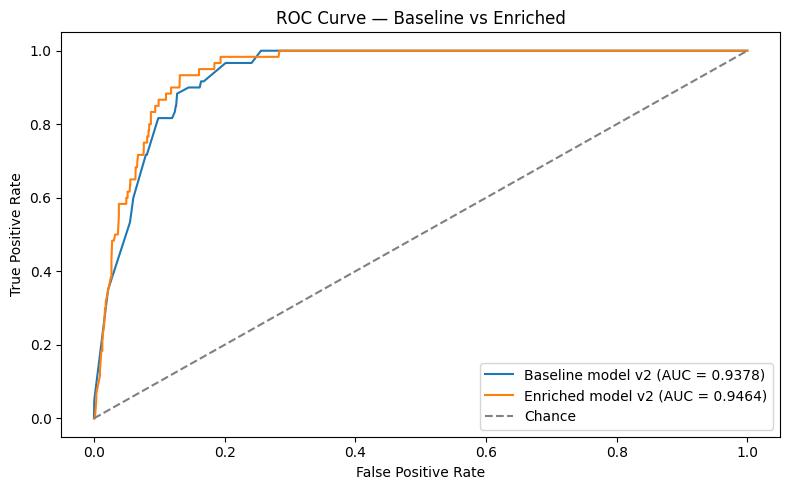

ROC comparison curve saved


In [14]:
# Roc curve - both models overlaid
from sklearn.metrics import roc_curve

fpr_baseline, tpr_baseline, _ = roc_curve(y_test, proba_baseline_v2)
fpr_enriched, tpr_enriched, _ = roc_curve(y_test, proba_enriched_v2)

auc_baseline = results_v2_df.loc['Baseline (test)', 'ROC-AUC']
auc_enriched = results_v2_df.loc['Enriched (test)', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(fpr_baseline, tpr_baseline, label=f"Baseline model v2 (AUC = {auc_baseline:.4f})")
ax.plot(fpr_enriched, tpr_enriched, label=f"Enriched model v2 (AUC = {auc_enriched:.4f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')

ax.set_title('ROC Curve — Baseline vs Enriched')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('/home/ubuntu/data/roc_curve_comparison_baseline_enriched.png', dpi=150)
plt.show()
print('ROC comparison curve saved')

### Results: Regularized Model Comparison (v2)

Retraining with reduced capacity (max_depth 3, 150 estimators, L2
regularization) and early stopping resolved the overfitting seen in v1.

**Train vs. test gap (overfitting check):**

|          | Train ROC-AUC | Test ROC-AUC | Train PR-AUC | Test PR-AUC |
|----------|---------------|--------------|---------------|-------------|
| Baseline | 0.9560        | 0.9378       | 0.3154        | 0.2681      |
| Enriched | 0.9703        | 0.9464       | 0.4077        | 0.2782      |

Both models now show a small, reasonable train/test gap instead of the
near-perfect train scores (0.999+) seen in v1 — confirming the models are
generalizing rather than memorizing.

**Baseline vs. enriched, on test:**

|          | ROC-AUC | PR-AUC |
|----------|---------|--------|
| Baseline | 0.9378  | 0.2681 |
| Enriched | 0.9464  | 0.2782 |

With overfitting controlled, the enriched model now outperforms baseline on
both metrics (+0.0086 ROC-AUC, +0.0101 PR-AUC) — a reversal from the
unreliable v1 result. This is a genuine, positive signal that the
LLM-derived narrative features add predictive value beyond the 8 structured
baseline features.

**Caveat:** the improvement is modest, and this is a single 10,000-row
sample with a small positive class (~239 train, ~60 test positives). This
result should be read as encouraging but not conclusive — a larger sample
would be needed to confirm the effect size with more confidence.

**Next:** SHAP analysis on the enriched v2 model, to identify which specific
LLM-derived features are driving the improvement.

## Step 17: SHAP Analysis on Enriched Model

Running SHAP on the regularized enriched model (v2) to see which specific
features — baseline or LLM-derived — are actually driving predictions. This
tells us not just that the enriched model performs better, but which of the
new narrative-derived features (harm_type, severity, sentiment_intensity,
discrimination_mentioned, resolution_requested) are contributing meaningfully,
versus which may be adding little beyond noise. Same approach as NB3's SHAP
analysis, applied here to compare against the original has_narrative flag's
importance.

In [17]:
# Feature importance 
feature_importance_df = pd.DataFrame({
    'features' : X_tr[enriched_cols].columns,
    'importance' : model_enriched_v2.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance - Enriched model")
print(feature_importance_df.to_string(index=False))

Feature Importance - Enriched model
                         features  importance
                            Issue    0.269264
         harm_type_financial_loss    0.113053
                          Company    0.106682
      resolution_requested_refund    0.097273
                  timely_response    0.073329
         harm_type_service_denial    0.058969
                        Sub-issue    0.040127
  resolution_requested_correction    0.031683
                     severity_low    0.022737
                    product_clean    0.022509
          harm_type_credit_damage    0.021152
resolution_requested_legal_action    0.020766
                            State    0.020321
 resolution_requested_none_stated    0.017975
                    severity_high    0.017231
                          has_tag    0.016400
   sentiment_intensity_frustrated    0.015857
        sentiment_intensity_irate    0.012390
         discrimination_mentioned    0.012347
         sentiment_intensity_calm    0.00778

In [19]:
import shap
import matplotlib.pyplot as plt

# # TreeExplainer - Optimized for XGBoost
explainer = shap.TreeExplainer(model_enriched_v2)
shap_values = explainer.shap_values(X_test_enc[enriched_cols])

print("SHAP values computed")
print(f"SHAP: {shap_values.shape}")

SHAP values computed
SHAP: (2000, 26)


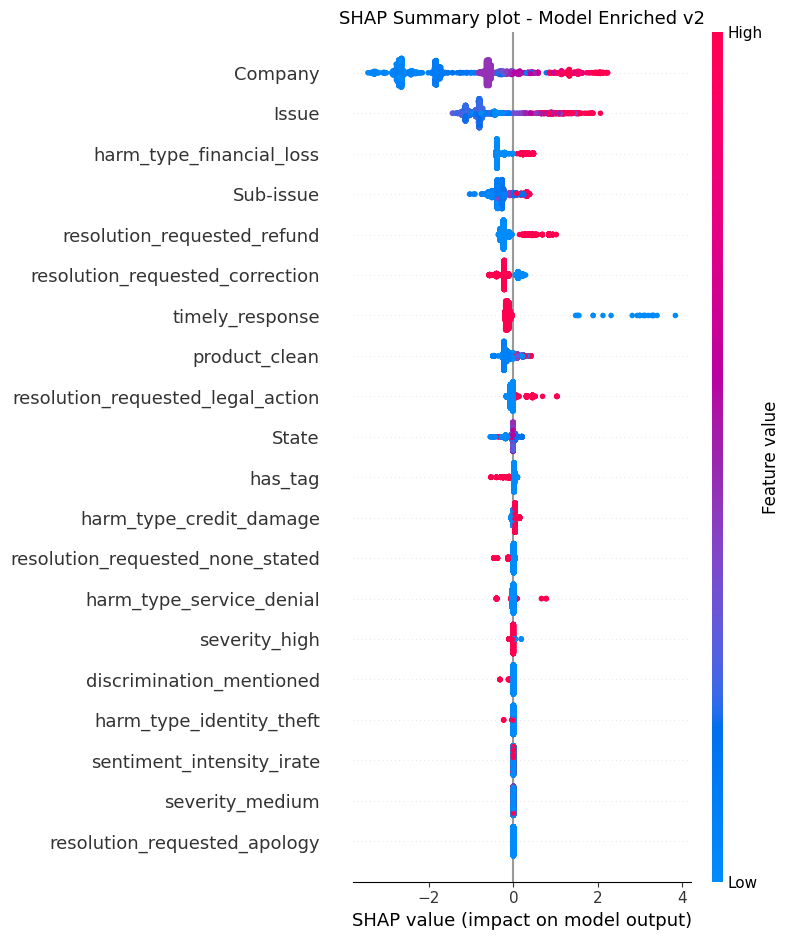

Summary plot saved


In [20]:
# Summary plot - feature importance + direction
# Each dot is one complaint from the sample
# Color : feature value(red = high, blue = low)
# X-axis : SHAP value - positive pushes towrds investigation, negative towards routine

# plot
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test_enc[enriched_cols],
    show = False
)

plt.title("SHAP Summary plot - Model Enriched v2", fontsize=13)
plt.tight_layout()
plt.savefig('/home/ubuntu/data/shap_summary_enriched_model_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary plot saved')

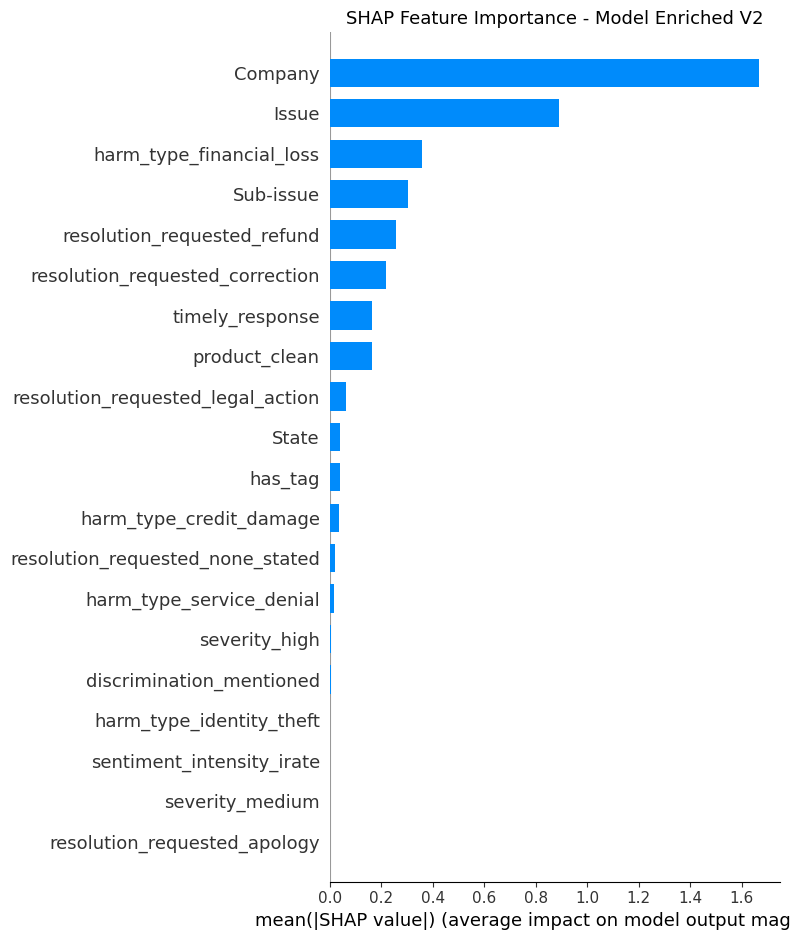

Bar plot saved


In [21]:
# Bar plot - mean absolute SHAP value per feature

plt.figure(figsize=(8,5))
shap.summary_plot(
    shap_values,
    X_test_enc[enriched_cols],
    plot_type = 'bar',
    show = False
)

plt.title("SHAP Feature Importance - Model Enriched V2", fontsize=13)
plt.tight_layout()
plt.savefig('/home/ubuntu/data/shap_bar_model_enrichedv2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved")

##  Results: SHAP Confirms and Explains the NB3 Finding

The enriched model's SHAP importance shows `has_narrative` at exactly 0.000000
— fully displaced from its #2 global ranking in NB3.

This is not a contradiction of the NB3 result — it explains it. NB3's SHAP
correctly identified that narrative presence carries real predictive signal,
but `has_narrative` was only a blunt proxy: it could tell the model *that*
context existed, not *what* that context was. The LLM-derived features are
extracted directly from the narrative text itself, so once they're available,
they capture the same underlying signal `has_narrative` was standing in for —
with far more precision (specific harm type, resolution requested, sentiment).
That's why `has_narrative` becomes redundant once these richer features are
present: the model no longer needs the flag when it has the substance.

**Top contributing LLM-derived features:** `harm_type_financial_loss`,
`resolution_requested_refund`, `harm_type_service_denial`,
`resolution_requested_correction`. These directly explain what `has_narrative`
could only gesture at.

## Save Final Artifacts: Model Enriched V2

Saving the regularized enriched model (v2) along with everything needed to
reproduce its predictions on new, unseen complaints: the model itself, the
exact column order it expects, and the list of baseline/LLM feature names.
The target encoder and its expected 8-column input are already saved from
NB3 (`target_encoder.pkl`) and reused here.

In [22]:
import json
import os

ARTIFACT_DIR_NB4 = '/home/ubuntu/data/nb4_artifacts'
os.makedirs(ARTIFACT_DIR_NB4, exist_ok=True)

# 1. The trained model itself
model_enriched_v2.save_model(f"{ARTIFACT_DIR_NB4}/model_enriched_v2.json")

# 2. The exact column order the model expects (critical — order must match at inference time)
enriched_cols = X_train_enc.columns.tolist()
with open(f"{ARTIFACT_DIR_NB4}/enriched_cols.json", "w") as f:
    json.dump(enriched_cols, f)

# 3. The baseline columns (subset that need target encoding)
baseline_cols = ['product_clean', 'Issue', 'Sub-issue', 'Company', 'State',
                  'has_tag', 'has_narrative', 'timely_response']
with open(f"{ARTIFACT_DIR_NB4}/baseline_cols.json", "w") as f:
    json.dump(baseline_cols, f)

# 4. The LLM-derived categorical columns (need one-hot encoding, same categories as training)
llm_categorical_cols = ['harm_type', 'severity', 'resolution_requested', 'sentiment_intensity']
with open(f"{ARTIFACT_DIR_NB4}/llm_categorical_cols.json", "w") as f:
    json.dump(llm_categorical_cols, f)

print("Saved:")
print(f"  {ARTIFACT_DIR_NB4}/model_enriched_v2.json")
print(f"  {ARTIFACT_DIR_NB4}/enriched_cols.json")
print(f"  {ARTIFACT_DIR_NB4}/baseline_cols.json")
print(f"  {ARTIFACT_DIR_NB4}/llm_categorical_cols.json")

Saved:
  /home/ubuntu/data/nb4_artifacts/model_enriched_v2.json
  /home/ubuntu/data/nb4_artifacts/enriched_cols.json
  /home/ubuntu/data/nb4_artifacts/baseline_cols.json
  /home/ubuntu/data/nb4_artifacts/llm_categorical_cols.json


In [24]:
with open(f"{ARTIFACT_DIR_NB4}/extraction_tool.json", "w") as f:
    json.dump(extraction_tool, f)

print(f"  {ARTIFACT_DIR_NB4}/extraction_tool.json")

  /home/ubuntu/data/nb4_artifacts/extraction_tool.json


## Conclusion

This notebook tested whether narrative *content* — extracted via LLM into
structured features — adds predictive value beyond simply knowing a
narrative *exists* (NB3's `has_narrative` flag).

**Process:** Extracted 5 structured features (harm_type, severity,
discrimination_mentioned, resolution_requested, sentiment_intensity) from
10,000 sampled complaint narratives using Claude's Batches API, validated
and corrected extraction errors (2 of 10,000 rows), merged with NB3's 8
baseline features, and trained parallel baseline vs. enriched XGBoost
models.

**Key finding:** An initial comparison (v1) was confounded by severe
overfitting (239 positive training examples, oversized model capacity).
After retraining with regularization and early stopping (v2), results
became trustworthy: the enriched model outperformed baseline on both
ROC-AUC (0.9464 vs. 0.9378) and PR-AUC (0.2782 vs. 0.2681).

**Why it works:** SHAP analysis showed `has_narrative` — NB3's #2 most
important feature — dropped to zero importance in the enriched model,
fully displaced by the LLM-derived features it was extracted from
(notably `harm_type_financial_loss`, `resolution_requested_refund`,
`harm_type_service_denial`). This confirms and explains NB3's original
finding: narrative presence carried real signal, and the LLM features
reveal what that signal actually was.

**Limitations:** Results are based on a single 10,000-row sample with a
small positive class (~239 train, ~60 test). The improvement, while real
and mechanistically well-explained, is modest in magnitude. A larger
sample would strengthen confidence in the effect size. Additionally, the
target encoder was reused from NB3's full-dataset fit without confirming
zero overlap between this sample and NB3's original training set — a
known limitation worth revisiting for a fully rigorous claim.

**Next steps (out of scope for this notebook):** scale to a larger
narrative sample to firm up effect size; build a lightweight deployment
demo (Streamlit) showcasing the full pipeline end-to-end.